In [66]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt
#from ipywidgets import interact, IntSlider

In [67]:
DIMENSIONS = 2 # number of dimensions of the PDE
BOUNDARIES = [
                [0.0, .80],  # Time boundaries
                [0.0, 1],  # x boundaries
             #charging current boundaries
                #[0.0, 1.0],  # y boundaries
                # Add more boundaries for additional dimensions if needed
            ]
####################################################################################



######################## NEURAL NETWORK ########################
NUMBER_HIDDEN_LAYERS = 2 # number of hidden layers in the neural network
NUMBER_NEURONS_PER_LAYER = 20 # number of neurons per hidden layer
ACTIVATION = tf.keras.activations.tanh # activation function
##################################################################



######################## DATA POINTS ########################
NUMBER_DATA_POINTS_PDE = 100 # number of random data points
NUMBER_DATA_POINTS_INITIAL_CONDITION = 100 # number of random initial condition data points
NUMBER_DATA_POINTS_BOUNDARY_CONDITION = 100 # number of random boundary condition data points
##################################################################



######################## TRAINING ########################
NUMBER_TRAINING_EPOCHS = 154000 # number of training iterations
PRINT_LOSS_INTERVAL = 10 # print the loss every PRINT_LOSS_INTERVAL training steps
PLOT_LOSS_HISTORY = True # boolean to plot or not plot the loss history after training
##################################################################



######################## SAVING THE MODEL ########################
CHEKPOINT_PATH = 'model_checkpoint' #path to save the model
CHECKPOINT_ITERATIONS = 10000 # save the model each CHECKPOINT_ITERATIONS iterations
##################################################################



######################## DATA TYPE ########################
DTYPE='float32' # Set data type
tf.keras.backend.set_floatx(DTYPE)
###########################################################



######################## PARAMETERS ########################
pi = tf.constant(np.pi)
D = .8e-16 # diffusion coeff
r = 1 # growth rate
############################################################



######################## Define initial condition ########################
def comp_i(X):
    """
    Assigns 0.04 to the first half of X and 0.84 to the second half.
    
    Parameters:
        X (numpy array): Input array of shape (N, D), where N is the number of samples.

    Returns:
        numpy array: An array of shape (N, 1) with values 0.04 for the first half
                     and 0.84 for the second half.
    """
    N = X.shape[0]  # Get the number of samples (rows)
    
    # Create an output array initialized with 0.04
    output = np.full((N, 1), 0.04)  
    
    # Assign 0.84 to the second half
    output[N//2:] = 0.84  
    
    return output



######################## Define the boundary condition ########################
CHOOSE_NEUMANN_BOUNDARY_CONDITION = True # if true->Neumann BC,   if false->Dirichlet BC

######################## NEUMANN BOUNDARY CONDITION ########################
def neuman_condition(I):
    NEUMANN_BOUNDARY_CONDITION =-0.197*I# the Neumann BC
    return NEUMANN_BOUNDARY_CONDITION



######################## DIRICHLET BOUNDARY CONDITION ########################
def DC_comp_b(prediction, x_b):

    # variables
    t = x_b[:,0:1]
    x = x_b[:,1:2]
    y = x_b[:,2:3]

    expected = tf.sin(pi*x)+tf.sin(pi*y) # expected output at the boundary

    return prediction - expected 




######################## Define residual of the PDE ########################
def comp_r(var, u, first_deriv, second_deriv):
    # Extracting first derivatives
    u_t = first_deriv[0]
    u_x = first_deriv[1]

    # Extracting the required second derivative
    u_xx = second_deriv[1]

    # Compute the PDE residual
    residual = u_t - (2/ var[1]) * u_x - u_xx

    return residual





######################## YOU DON'T NEED TO MODIFY THIS FUNCTION ########################
######################## residual of neumann boundary condition ########################
def NBC_comp_b(var, first_derivatives, lower_boundary, upper_boundary,current_values):

    neumann_boundary_condition = neuman_condition(current_values) # get the neumann boundary condition

    return_tensor = tf.zeros_like(var[1]) # init the return tensor

    for i in range(1,len(var)): # we start from 1 to skip the time variable
        comparison_tensor = tf.equal(var[i], upper_boundary[i]) # is our tensor on the boundaries?
        return_tensor += tf.where(
                                    comparison_tensor, 
                                    [first_derivatives[i]-neumann_boundary_condition,first_derivatives[i]-neumann_boundary_condition], 
                                    0
                                ) # if it is in the boundary then return the first derivative of that variable minus the neumann BC, if not 0

    return return_tensor
import tensorflow as tf

def apply_neumann_boundary_condition(var, first_derivatives, lower_boundary, upper_boundary):
    # Neumann boundary condition value: derivative is zero at x=0
    neumann_boundary_value = 0.0

    # Initialize a tensor to store the boundary condition application
    neumann_bc_application = tf.zeros_like(var[1])  # Assuming var[1] is 'x'

    # Loop over the variables, starting from 1 to skip the time variable
    for i in range(1, len(var)):
        # Apply the boundary condition only to the x variable
        if i == 1:  # Assuming var[1] is 'x'
            # Check if x is at its lower boundary (i.e., x=0)
            is_at_lower_boundary = tf.equal(var[i], lower_boundary[i])

            # Apply the boundary condition: (first_derivative - neumann_boundary_value) at x=0
            neumann_bc_application += tf.where(
                is_at_lower_boundary, 
                first_derivatives[i] - neumann_boundary_value, 
                0.0
            )

    return neumann_bc_application

# Example usage
# var: tensor containing variables (e.g., [t, x])
# first_derivatives: tensor containing the first derivatives with respect to each variable
# lower_boundary and upper_boundary: tensors containing the lower and upper boundary values for each variable



In [68]:
N_0 = NUMBER_DATA_POINTS_INITIAL_CONDITION  # Number of initial condition data points
N_b = NUMBER_DATA_POINTS_BOUNDARY_CONDITION  # Number of boundary data points
N_r = NUMBER_DATA_POINTS_PDE  # Number of PDE data points

# Define the boundaries for each dimension
boundaries = BOUNDARIES

# Set the lower and upper bounds as tensors
lb = tf.constant([boundaries[i][0] for i in range(len(boundaries))], dtype=DTYPE)  # Lower bounds
ub = tf.constant([boundaries[i][1] for i in range(len(boundaries))], dtype=DTYPE)  # Upper bounds


################ Set random seed for reproducible results or remove it for different results ################
tf.random.set_seed(0)






In [69]:
ub

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([0.8, 1. ], dtype=float32)>

In [70]:
N_0 = NUMBER_DATA_POINTS_INITIAL_CONDITION  # Number of initial condition data points
N_b = NUMBER_DATA_POINTS_BOUNDARY_CONDITION  # Number of boundary data points
N_r = NUMBER_DATA_POINTS_PDE  # Number of PDE data points

# Define the boundaries for each dimension
boundaries = BOUNDARIES
N_0=100
# Set the lower and upper bounds as tensors
lb = tf.constant([boundaries[i][0] for i in range(len(boundaries))], dtype=DTYPE)  # Lower bounds
ub = tf.constant([boundaries[i][1] for i in range(len(boundaries))], dtype=DTYPE)  # Upper bounds


################ Set random seed for reproducible results or remove it for different results ################
tf.random.set_seed(0)

N_0_half = N_0 // 2  # Half of the initial condition data points

################################ Initial data ################################
t_0_half = tf.ones((N_0_half, 1), dtype=DTYPE) * lb[0]  # Time values for initial condition
other_0_half = tf.cast(tf.linspace(lb[1], ub[1], N_0_half), dtype=DTYPE)
#other_0=tf.ones((N_0, 1), dtype=DTYPE) * lb[0] 
X_0_half,T_0_half=tf.meshgrid(other_0_half,t_0_half)
X_0_half_flat=tf.reshape(X_0_half,(-1,1))
T_0_half_flat=tf.reshape(T_0_half,(-1,1))
X_half_iniitial=tf.concat([T_0_half_flat,X_0_half_flat],axis=1)
t_0_second_half = tf.ones((N_0_half, 1), dtype=DTYPE) * lb[0]  # Time values for initial condition
other_0_second_half = tf.cast(tf.linspace(lb[1], ub[1], N_0_half), dtype=DTYPE)
X_0_second_half,T_0_second_half=tf.meshgrid(other_0_second_half,t_0_second_half)
X_0_second_half_flat=tf.reshape(X_0_second_half,(-1,1))
T_0_second_half_flat=tf.reshape(T_0_second_half,(-1,1))
X_second_half_iniitial=tf.concat([T_0_second_half_flat,X_0_second_half_flat],axis=1)


In [71]:
X_second_half_iniitial

<tf.Tensor: shape=(2500, 2), dtype=float32, numpy=
array([[0.        , 0.        ],
       [0.        , 0.02040816],
       [0.        , 0.04081633],
       ...,
       [0.        , 0.95918363],
       [0.        , 0.97959185],
       [0.        , 1.        ]], dtype=float32)>

In [72]:
Total_initial=tf.concat([X_half_iniitial,X_second_half_iniitial],axis=0)
X_0_half_flat.shape

TensorShape([2500, 1])

In [73]:
ub

<tf.Tensor: shape=(2,), dtype=float32, numpy=array([0.8, 1. ], dtype=float32)>

In [74]:
new_time=tf.constant([0.4,0.8],dtype=DTYPE)

In [75]:
N_b=100

In [76]:

################################ Boundary data ################################
N_b_half = N_b // 2  # Half of the boundary condition data points
t_b_half = tf.cast(tf.linspace(tf.constant(0, dtype=DTYPE), ub[0]/2.0, N_b_half), dtype=DTYPE) # Time values for boundary condition
other_b_half = tf.ones((N_b_half, 1), dtype=DTYPE) * ub[1]  # x values for boundary condition
X_b_half,T_b_half=tf.meshgrid(other_b_half,t_b_half)
X_b_half_flat=tf.reshape(X_b_half,(-1,1))
T_b_half_flat=tf.reshape(T_b_half,(-1,1))
X_half_boundary=tf.concat([T_b_half_flat,X_b_half_flat],axis=1)
t_b_second_half = tf.linspace(ub[0]/2.0, ub[0], N_b_half)  # Time values for boundary condition
other_b_second_half = tf.ones((N_b_half, 1), dtype=DTYPE) * ub[1]  # x values for boundary condition
X_b_second_half,T_b_second_half=tf.meshgrid(other_b_second_half,t_b_second_half)
X_b_second_half_flat=tf.reshape(X_b_second_half,(-1,1))
T_b_second_half_flat=tf.reshape(T_b_second_half,(-1,1))
X_second_half_boundary=tf.concat([T_b_second_half_flat,X_b_second_half_flat],axis=1)
Total_boundary=tf.concat([X_half_boundary,X_second_half_boundary],axis=0)
Total_boundary








<tf.Tensor: shape=(5000, 2), dtype=float32, numpy=
array([[0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       ...,
       [0.8, 1. ],
       [0.8, 1. ],
       [0.8, 1. ]], dtype=float32)>

In [77]:
X_half_boundary

<tf.Tensor: shape=(2500, 2), dtype=float32, numpy=
array([[0. , 1. ],
       [0. , 1. ],
       [0. , 1. ],
       ...,
       [0.4, 1. ],
       [0.4, 1. ],
       [0.4, 1. ]], dtype=float32)>

In [78]:
Total_boundary_neuman = tf.concat([tf.expand_dims(Total_boundary[:, 0], axis=1), tf.zeros_like(tf.expand_dims(Total_boundary[:, 1], axis=1))], axis=1)


In [79]:
Total_boundary_neuman

<tf.Tensor: shape=(5000, 2), dtype=float32, numpy=
array([[0. , 0. ],
       [0. , 0. ],
       [0. , 0. ],
       ...,
       [0.8, 0. ],
       [0.8, 0. ],
       [0.8, 0. ]], dtype=float32)>

In [80]:
N_r=100

In [81]:
import tensorflow as tf

# Define bounds and number of random samples

# Generate the time values (equivalent to torch.arange and unsqueeze)
N_r_half=N_r//2
t_r_half = tf.cast(tf.linspace(lb[0], ub[0]/2.0, N_r_half), dtype=DTYPE)  # Time values for PDE data points
other_r_half = tf.cast(tf.linspace(lb[1], ub[1], N_r_half), dtype=DTYPE)  # x values for PDE data points
X_r_half,T_r_half=tf.meshgrid(other_r_half,t_r_half)
X_r_half_flat=tf.reshape(X_r_half,(-1,1))
T_r_half_flat=tf.reshape(T_r_half,(-1,1))
X_half_PDE=tf.concat([T_r_half_flat,X_r_half_flat],axis=1)
t_r_second_half = tf.cast(tf.linspace(ub[0]/2.0, ub[0], N_r_half), dtype=DTYPE)  # Time values for PDE data points
other_r_second_half = tf.cast(tf.linspace(lb[1], ub[1], N_r_half), dtype=DTYPE)  # x values for PDE data points
X_r_second_half,T_r_second_half=tf.meshgrid(other_r_second_half,t_r_second_half)
X_r_second_half_flat=tf.reshape(X_r_second_half,(-1,1))
T_r_second_half_flat=tf.reshape(T_r_second_half,(-1,1))
X_second_half_PDE=tf.concat([T_r_second_half_flat,X_r_second_half_flat],axis=1)
Total_PDE=tf.concat([X_half_PDE,X_second_half_PDE],axis=0)



In [82]:

random_t = tf.random.uniform([N_r, 1], minval=lb[0], maxval=ub[0], dtype=DTYPE)  # Random t values
random_x = tf.random.uniform([N_r, 1], minval=lb[1], maxval=ub[1], dtype=DTYPE)  # Random x values

# Combine into a single tensor
random_samples = tf.concat([random_t, random_x], axis=1)

# Apply filtering to remove (t=0, x=0, t=1)
valid_mask = tf.logical_not(
    tf.logical_or(
        tf.equal(random_samples[:, 0], 0.0),  # t == 0
        tf.logical_or(
            tf.equal(random_samples[:, 1], 0.0),  # x == 0
            tf.equal(random_samples[:, 0], 1.0)  # t == 1
        )
    )
)

# Apply the mask to get valid samples
filtered_random_samples = tf.boolean_mask(random_samples, valid_mask)

# Ensure the final dataset has the same size as `Total_PDE`
final_random_samples = tf.random.shuffle(filtered_random_samples)[:tf.shape(Total_PDE)[0]]

# Print the output shape
print("Output Shape:", tf.shape(final_random_samples))


Output Shape: tf.Tensor([100   2], shape=(2,), dtype=int32)


In [83]:
final_random_samples

<tf.Tensor: shape=(100, 2), dtype=float32, numpy=
array([[5.84902465e-01, 2.51465917e-01],
       [4.70519155e-01, 3.03776979e-01],
       [6.66778862e-01, 1.20990753e-01],
       [3.36414635e-01, 1.07879400e-01],
       [3.65053192e-02, 5.84960938e-01],
       [1.38170242e-01, 4.59002018e-01],
       [7.31050432e-01, 2.11380839e-01],
       [1.65253162e-01, 2.21292973e-01],
       [5.86566925e-01, 7.20187426e-01],
       [1.24185560e-02, 8.44630122e-01],
       [2.33580112e-01, 5.55414081e-01],
       [6.46262348e-01, 5.30362248e-01],
       [4.78033155e-01, 7.24475265e-01],
       [4.74510193e-02, 2.95720100e-02],
       [1.40623569e-01, 6.87643886e-01],
       [4.85022753e-01, 8.56696844e-01],
       [4.73306566e-01, 3.17375064e-01],
       [3.79223824e-01, 9.17217970e-01],
       [5.84669132e-03, 3.10113907e-01],
       [1.36149317e-01, 2.77866721e-01],
       [4.26182359e-01, 9.83630896e-01],
       [5.37285507e-01, 7.95041800e-01],
       [5.43893337e-01, 4.61516857e-01],
       

In [84]:
Total_PDE

<tf.Tensor: shape=(5000, 2), dtype=float32, numpy=
array([[0.        , 0.        ],
       [0.        , 0.02040816],
       [0.        , 0.04081633],
       ...,
       [0.8       , 0.95918363],
       [0.8       , 0.97959185],
       [0.8       , 1.        ]], dtype=float32)>

In [85]:
N_b=10

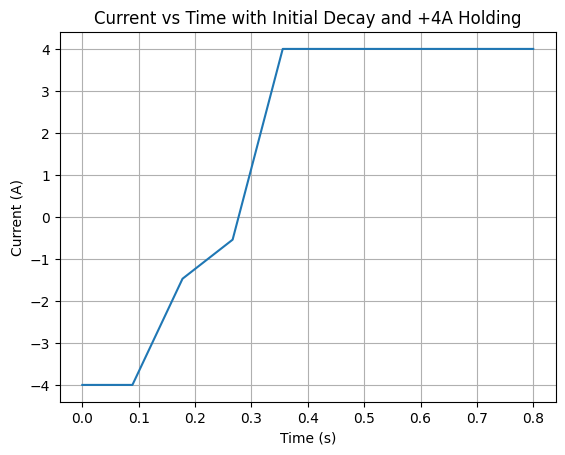

In [86]:
import tensorflow as tf
import matplotlib.pyplot as plt



# Generate the time points
time_points = tf.linspace(lb[0], ub[0], N_b)

# Define key time indices
first_12_5_percent_index = tf.cast(0.125 * N_b, tf.int32)  # First 12.5% mark
decay_duration = tf.cast((0.5-0.125) * N_b, tf.int32)  # Decay period (let’s say 20% of total time)
decay_end_index = first_12_5_percent_index + decay_duration  # Index when decay should end

# Define the decay function: Exponential decay from -4A to 0A
decay_start_time = time_points[first_12_5_percent_index:decay_end_index]
decay_values = -4 * tf.exp(-8 * (decay_start_time - time_points[first_12_5_percent_index]) / (ub[0] - time_points[first_12_5_percent_index]))

# Pad decay_values to fit the entire time sequence
current_values=tf.concat([tf.fill([first_12_5_percent_index], -4.0), decay_values, tf.zeros(N_b - decay_end_index)+4], axis=0)

# Plot the result
plt.plot(time_points, current_values)
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.title('Current vs Time with Initial Decay and +4A Holding')
plt.grid(True)
plt.show()


In [87]:
decay_values

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([-4.       , -1.4715178, -0.541341 ], dtype=float32)>

In [88]:
current_values_mesh=np.repeat(current_values[:,np.newaxis],N_b_half,axis=1)
current_values_mesh.flatten().shape

(500,)

In [89]:
current_values_tensor=tf.constant(current_values_mesh.flatten(),dtype=DTYPE)

In [90]:
import tensorflow as tf

def init_model(num_hidden_layers=NUMBER_HIDDEN_LAYERS, 
               num_neurons_per_layer=NUMBER_NEURONS_PER_LAYER, 
               current_values=None):
    # Input: x and I
    input_var = tf.keras.Input(shape=(2,))  # input_var with shape (100, 2)
    
    # Check if current_values is provided
    if current_values is not None:
        input_values = tf.keras.Input(shape=(1,))  # current_values with shape (100, 1)
        
        # Scaling layer to map [lb, ub] to [0,1] (Assume lb and ub are predefined)
        scaling_layer = tf.keras.layers.Lambda(lambda x: (x - lb) / (ub - lb))(input_var)
        
        # Concatenate inputs
        concatenated_inputs = tf.keras.layers.Concatenate()([scaling_layer, input_values])
        
        x = concatenated_inputs
        print(x)
    else:
        # Scaling layer to map [lb, ub] to [0,1] if no current_values
        #x = tf.keras.layers.Lambda(lambda x: (x - lb) / (ub - lb))(input_var)
        x=input_var
    
    # Add hidden layers
    for _ in range(num_hidden_layers):
        x = tf.keras.layers.Dense(num_neurons_per_layer,
                                  activation=ACTIVATION,
                                  kernel_initializer='glorot_normal')(x)

    # Output layer
    output = tf.keras.layers.Dense(1)(x)

    if current_values is not None:
        # Define the model with multiple inputs if current_values is provided
        model = tf.keras.Model(inputs=[input_var, input_values], outputs=output)
    else:
        # Define the model with only input_var if current_values is not provided
        model = tf.keras.Model(inputs=input_var, outputs=output)

    return model


In [91]:
model = init_model()



In [92]:
model(final_random_samples)


<tf.Tensor: shape=(100, 1), dtype=float32, numpy=
array([[ 0.2002485 ],
       [ 0.13883874],
       [ 0.26422998],
       [ 0.12807032],
       [-0.12494431],
       [-0.04935263],
       [ 0.26808247],
       [ 0.02159358],
       [ 0.08658475],
       [-0.19106174],
       [-0.02899231],
       [ 0.15761031],
       [ 0.03918544],
       [ 0.01475819],
       [-0.1015402 ],
       [ 0.0111732 ],
       [ 0.13669033],
       [-0.0479669 ],
       [-0.07423369],
       [-0.00597448],
       [-0.04250288],
       [ 0.04787276],
       [ 0.1315393 ],
       [-0.12608267],
       [-0.02617426],
       [ 0.03391739],
       [ 0.02126002],
       [-0.12638672],
       [ 0.08111016],
       [ 0.265739  ],
       [-0.0817408 ],
       [-0.07271266],
       [-0.15766871],
       [ 0.15826663],
       [ 0.2148059 ],
       [-0.10286495],
       [ 0.14392245],
       [-0.12184408],
       [ 0.23380898],
       [ 0.06294445],
       [ 0.07615823],
       [-0.09840697],
       [ 0.07254589],
    

In [93]:
def NBC_comp_b(var, first_derivatives, lower_boundary, upper_boundary,current_values):

    neumann_boundary_condition = neuman_condition(current_values) # get the neumann boundary condition

    return_tensor = tf.zeros_like(var[1]) # init the return tensor

    for i in range(1,len(var)): # we start from 1 to skip the time variable
        comparison_tensor = tf.equal(var[i], upper_boundary[i]) # is our tensor on the boundaries?
        return_tensor += tf.where(
                                    comparison_tensor, 
                                    [first_derivatives[i]-neumann_boundary_condition,first_derivatives[i]-neumann_boundary_condition], 
                                    0
                                ) # if it is in the boundary then return the first derivative of that variable minus the neumann BC, if not 0

    return return_tensor
import tensorflow as tf

In [94]:
import tensorflow as tf

def init_model(num_hidden_layers=NUMBER_HIDDEN_LAYERS, 
               num_neurons_per_layer=NUMBER_NEURONS_PER_LAYER, 
               current_values=None):
    # Input: x and I
    input_var = tf.keras.Input(shape=(2,))  # input_var with shape (100, 2)
    
    # Check if current_values is provided
    if current_values is not None:
        input_values = tf.keras.Input(shape=(1,))  # current_values with shape (100, 1)
        
        # Scaling layer to map [lb, ub] to [0,1] (Assume lb and ub are predefined)
        scaling_layer = tf.keras.layers.Lambda(lambda x: (x - lb) / (ub - lb))(input_var)
        
        # Concatenate inputs
        concatenated_inputs = tf.keras.layers.Concatenate()([scaling_layer, input_values])
        
        x = concatenated_inputs
        print(x)
    else:
        # Scaling layer to map [lb, ub] to [0,1] if no current_values
        #x = tf.keras.layers.Lambda(lambda x: (x - lb) / (ub - lb))(input_var)
        x=input_var
    
    # Add hidden layers
    for _ in range(num_hidden_layers):
        x = tf.keras.layers.Dense(num_neurons_per_layer,
                                  activation=ACTIVATION,
                                  kernel_initializer='glorot_normal')(x)

    # Output layer
    output = tf.keras.layers.Dense(1)(x)

    if current_values is not None:
        # Define the model with multiple inputs if current_values is provided
        model = tf.keras.Model(inputs=[input_var, input_values], outputs=output)
    else:
        # Define the model with only input_var if current_values is not provided
        model = tf.keras.Model(inputs=input_var, outputs=output)

    return model


In [95]:
model = init_model()


In [96]:
def NBC_comp_b(var, first_derivatives, lower_boundary, upper_boundary,current_values):

    neumann_boundary_condition = neuman_condition(current_values) # get the neumann boundary condition

    return_tensor = tf.zeros_like(var[1]) # init the return tensor

    for i in range(1,len(var)): # we start from 1 to skip the time variable
        comparison_tensor = tf.equal(var[i], upper_boundary[i]) # is our tensor on the boundaries?
        return_tensor += tf.where(
                                    comparison_tensor, 
                                    [first_derivatives[i]-neumann_boundary_condition,first_derivatives[i]-neumann_boundary_condition], 
                                    0
                                ) # if it is in the boundary then return the first derivative of that variable minus the neumann BC, if not 0

    return return_tensor
import tensorflow as tf

In [97]:
################ Get residual of PDE ################
def get_r(model, X_r,current_values):
    #current_values_expand=tf.expand_dims(current_values, axis=1)
    # Compute derivatives
    with tf.GradientTape(persistent=True) as tape: # A tf.GradientTape is used to compute derivatives in TensorFlow

        # split variables to compute partial derivatives
        variables = []
        for i in range(DIMENSIONS):
            variables.append(X_r[:,i:i+1])
    
        
        # watch the variables
        for i in range(DIMENSIONS):
            tape.watch(variables[i])
        
        
        stack = [] #stack the variables to feed the model
        for i in range(DIMENSIONS):
            stack.append(variables[i][:,0]) # add to list to stack, drop the second dimension

        # Determine residual 
        u = model((tf.stack(stack, axis=1)))
        
        # Compute the first gradients
        first_derivatives = [] 
        for i in range(DIMENSIONS): # we compute this derivatives within the gradient tape because we need the second derivatives 
            first_derivatives.append(tape.gradient(u, variables[i])) 


    # Compute the second derivatives 
    second_derivatives = [] # choose which second derivatives you want, there are on the order [x,y,z,...]->[u_xx,u_yy,u_zz,...]
    for i in range(DIMENSIONS):
        second_derivatives.append(tape.gradient(first_derivatives[i], variables[i]))

    del tape

    return comp_r(variables, u, first_derivatives, second_derivatives)




################ Get residual of boundary condition ################
def get_b_r(model ,x_b,current_values,discount_factor):
    #current_values_expand=tf.expand_dims(current_values, axis=1)
    if CHOOSE_NEUMANN_BOUNDARY_CONDITION==False: # if we have Dirichlet Boundary Condition
        prediction = model(x_b)
        return DC_comp_b(prediction,x_b)
    
    else:
        # Compute the derivatives
        with tf.GradientTape(persistent=True) as tape: # A tf.GradientTape is used to compute derivatives in TensorFlow
            
            # split variables to compute partial derivatives
            variables = []
            for i in range(DIMENSIONS):
                variables.append(x_b[:,i:i+1])

            # watch variables
            for i in range(DIMENSIONS):
                tape.watch(variables[i])

            
            
            stack = [] # stack the variables to feed the model
            for i in range(DIMENSIONS):
                stack.append(variables[i][:,0]) # addd to list to stack, drop the second dimension
            
            # Determine residual
            u =model((tf.stack(stack, axis=1)))
            
        # Compute the first gradients
        first_derivatives = [0] # remove the 0 and start the loop from 0 if you also need the time derivative
        for i in range(1,DIMENSIONS): # we skip the derivative of time since we don't need it for boundary contitions
            first_derivatives.append(tape.gradient(u, variables[i]))


        del tape


        return NBC_comp_b(variables,first_derivatives,lb,ub,current_values)*discount_factor
def get_b_r_n(model,x_b_n,current_values,discount_factor):
    #current_values_expand=tf.expand_dims(current_values, axis=1)
    with tf.GradientTape(persistent=True) as tape: # A tf.GradientTape is used to compute derivatives in TensorFlow
            
            # split variables to compute partial derivatives
            variables = []
            for i in range(DIMENSIONS):
                variables.append(x_b_n[:,i:i+1])

            # watch variables
            for i in range(DIMENSIONS):
                tape.watch(variables[i])

            
            
            stack = [] # stack the variables to feed the model
            for i in range(DIMENSIONS):
                stack.append(variables[i][:,0]) # addd to list to stack, drop the second dimension
            
            # Determine residual
            u = model((tf.stack(stack, axis=1)))
            
        # Compute the first gradients
    first_derivatives = [0] # remove the 0 and start the loop from 0 if you also need the time derivative
    for i in range(1,DIMENSIONS): # we skip the derivative of time since we don't need it for boundary contitions
        first_derivatives.append(tape.gradient(u, variables[i]))


        del tape
    
    return apply_neumann_boundary_condition(variables,first_derivatives,lb,ub)*discount_factor




################ Get residual of initial condition ################
def get_i_r(model, x_0,current_values):
    #current_values_expand=tf.expand_dims(current_values, axis=1)
    return comp_i(x_0) - model(x_0)




################ Get loss ################
def compute_loss(model, x_r, x_b, x_0,X_b_n,current_values,discount_factor):

    # Compute phi^r
    r = get_r(model, x_r,current_values)
    phi_r = tf.reduce_mean(tf.square(r))

    # compute phi^b
    b = get_b_r(model, x_b,current_values,discount_factor)
    phi_b = tf.reduce_mean(tf.square(b))

    # Compute phi^0
    i = get_i_r(model, x_0,current_values)
    phi_0 = tf.reduce_mean(tf.square(i))

    b_n=get_b_r_n(model,X_b_n,current_values,discount_factor)
    phi_b_n=tf.reduce_mean(tf.square(b_n))
    # Initialize loss
    loss = phi_r +(phi_b+phi_b_n) + phi_0

    return loss



################ Get gradient of the loss function ################
def get_grad(model, x_r, x_b, x_0, X_b_n, current_values,discount_factor):
    #discount_factor=1.0
    #current_values=-1.0
    with tf.GradientTape(persistent=True) as tape:
        # No need to watch trainable variables manually
        # Compute the loss (assuming you have a function `compute_loss` defined)
        loss = compute_loss(model, x_r, x_b, x_0, X_b_n, current_values,discount_factor)

    # Compute the gradients of the loss with respect to the model's trainable variables
    gradients = tape.gradient(loss, model.trainable_variables)
    
    return loss, gradients

In [98]:
discount_factor=1.0


In [99]:
Total_PDE=final_random_samples

In [100]:
#check the tupe of the input data make usete the tf.constant
input_data_collocation = tf.constant(Total_PDE, dtype=DTYPE)
input_data_b = tf.constant(Total_boundary, dtype=DTYPE)
input_data_0 = tf.constant(Total_initial, dtype=DTYPE)
input_data_b_n=tf.constant(Total_boundary_neuman, dtype=DTYPE)
current_values=tf.constant(current_values_tensor,dtype=DTYPE)



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 20)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 0, Loss: 1707.205322265625
Epoch 100, Loss: 0.8123562335968018
Epoch 200, Loss: 0.7443228363990784
Epoch 300, Loss: 0.7137725949287415
Epoch 400, Loss: 0.6975877285003662
Epoch 500, Loss: 0.6897019147872925
Epoch 600, Loss: 0.6858828663825989
Epoch 700, Loss: 0.6837638020515442
Epoch 800, Loss: 0.6822701096534729
Epoch 900, Loss: 0.6809993386268616
Epoch 1000, Loss: 0.6798273921012878
Epoch 1100, Loss: 0.6787192225456238
Epoch 1200, Loss: 0.6776652932167053
Epoch 1300, Loss: 0.6766608953475952
Epoch 1400, Loss: 0.6756988167762756
Epoch 1500, Loss: 0.6747746467590332
Epoch 1600, Loss: 0.6738818287849426
Epoch 1700, Loss: 0.6730136871337891
Epoch 1800, Loss: 0.6721634864807129
Epoch 1900, Loss: 0.671325147151947
Epoch 2000, Loss: 0.6704917550086975
Epoch 2100, Loss: 0.6696577072143555
Epoch 2200, Loss: 0.6688170433044434
Epoch 2300, Loss: 0.6679649353027344
Epoch 2400, Loss: 0.6670962572097778
Epoch 2500, Loss: 0.6662068367004395
Epoch 2600, Loss: 0.6652931571006775
Epoch 2700, Los

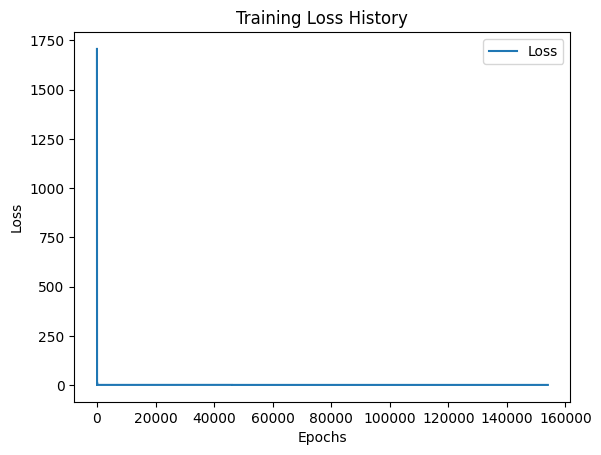

In [101]:
import tensorflow as tf
import tensorflow_probability as tfp  # Import TensorFlow Probability for L-BFGS
import time
import matplotlib.pyplot as plt

# Set checkpoint file path and device
#checkpoint_filepath = CHECKPOINT_PATH
device = '/GPU:0'  # Specify the device to run on (e.g., GPU)

# Initialize model, optimizer, and training setup within the device context
with tf.device(device):
    # Initialize model
    model = init_model()

    # Choose the optimizer (Adam for initial training phase)
    adam_optim = tf.keras.optimizers.Adam()

    # Define one training step for Adam
    @tf.function  # Defining the training step as a TensorFlow function
    def train_step_adam(optimizer):
        # Compute current loss and gradient w.r.t. parameters
        loss, grad_theta = get_grad(model, input_data_collocation, input_data_b, input_data_0,input_data_b_n, current_values,discount_factor)

        # Perform gradient descent step
        optimizer.apply_gradients(zip(grad_theta, model.trainable_variables))

        return loss

    # Define one training step for L-BFGS (uses tensorflow-probability optimizer)
    def train_step_lbfgs():
        def loss_and_grads(position):
            # Set model parameters to the current position
            start = 0
            for var in model.trainable_variables:
                var_shape = tf.shape(var)
                size = tf.reduce_prod(var_shape)
                new_value = tf.reshape(position[start:start + size], var_shape)
                var.assign(new_value)
                start += size

            # Compute loss
            with tf.GradientTape() as tape:
                loss, _ = get_grad(model, X_r, X_b, X_0, X_b_n, current_values,discount_factor)
            loss_log = tf.math.log(loss + 1e-10) # Log-transform loss for numerical stability
            # Compute gradients outside of the `with` block to avoid the warning
            grads = tape.gradient(loss, model.trainable_variables)
            grads_flat = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)  # Flatten gradients

            return loss_log, grads_flat

        # Initial position (flatten model parameters)
        initial_position = tf.concat([tf.reshape(v, [-1]) for v in model.trainable_variables], axis=0)

        # Run L-BFGS optimization using TensorFlow Probability
        results = tfp.optimizer.lbfgs_minimize(
            value_and_gradients_function=loss_and_grads,
            initial_position=initial_position,
            tolerance=1e-8,  # You can adjust tolerance for convergence
            max_iterations=10  # You can adjust the number of L-BFGS iterations
        )

        # After optimization, update model variables with the L-BFGS result
        pos = results.position
        start = 0
        for var in model.trainable_variables:
            var_shape = tf.shape(var)
            size = tf.reduce_prod(var_shape)
            new_value = tf.reshape(pos[start:start + size], var_shape)
            var.assign(new_value)
            start += size

        return results.objective_value


    # Number of total training epochs
    N = NUMBER_TRAINING_EPOCHS

    # Loss history
    hist = []

    # Adam training duration (epochs)
    adam_epochs = 155000  # Define the number of epochs to run Adam optimizer
    min_loss = float('inf')  # Initialize with infinity
    patience = 10000  # Patience for early stopping during Adam phase
    wait = 1000  # Counter for epochs without improvement
    tolerance = 1e-4  # Tolerance for considering the loss as "improved"

    # Start timer
    t0 = time.time()

    # Print model summary
    model.summary()

    # Training loop
    for i in range(N + 1):
        # Phase 1: Adam optimization
        if i < adam_epochs:
            loss = train_step_adam(adam_optim)
        else:
            # Phase 2: Switch to L-BFGS optimization
            if i == adam_epochs:
                print(f"Switching to L-BFGS optimizer at epoch {i}")
            loss = train_step_lbfgs()

        # Append current loss to history
        hist.append(loss.numpy())

        # Check if the current loss is a new minimum
        #if loss.numpy() < min_loss - tolerance:
            #min_loss = loss.numpy()  # Update the minimum loss
            #wait = 0  # Reset the patience counter
        #else:
            #wait += 1  # Increment the patience counter

        # Optional: Print loss at intervals
        if i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss.numpy()}")

        # Early stopping if no improvement
        if wait > patience:
            print("Early stopping due to lack of improvement.")
            break

    # End of training
    print(f"Training completed in {time.time() - t0:.2f} seconds")

# Plot the loss history
plt.plot(hist, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.show()


In [105]:
import tensorflow as tf

# Define the fixed value for the first column (e.g., x = 5)
x_value = 1.0

# Create an array of shape (100, 2)
fixed_x_column = tf.fill([1200, 1], x_value)
linear_space_column = tf.linspace(0.0, 3, 1200)


# Concatenate to form the final array
final_array = tf.concat([tf.reshape(linear_space_column, [-1, 1]),fixed_x_column], axis=1)

# View the result
final_array_np = final_array.numpy()
print(final_array_np)


[[0.0000000e+00 1.0000000e+00]
 [2.5020852e-03 1.0000000e+00]
 [5.0041704e-03 1.0000000e+00]
 ...
 [2.9949961e+00 1.0000000e+00]
 [2.9974980e+00 1.0000000e+00]
 [3.0000000e+00 1.0000000e+00]]


In [106]:
y_pred = model(final_array).numpy()
y_pred

array([[ 0.36975586],
       [ 0.36792445],
       [ 0.3660835 ],
       ...,
       [-1.200284  ],
       [-1.2006421 ],
       [-1.2009989 ]], dtype=float32)

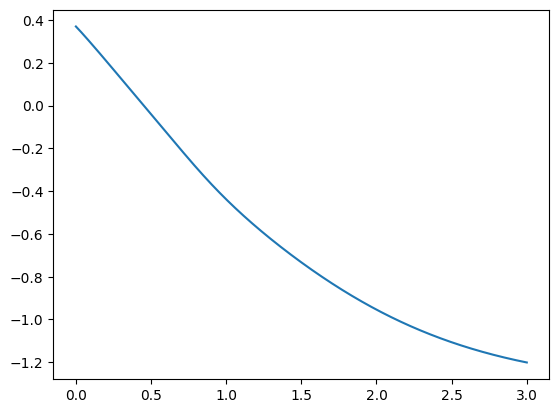

In [107]:
plt.plot(final_array_np[:, 0], y_pred, label='Predicted')